In [ ]:
# ==== Paths & Imports (robust) ====
import os, sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
import pandas as pd
import cv2


def add_repo_root(pkg_name="kaggle"):
    here = Path(os.getcwd()).resolve()
    for p in [here] + list(here.parents):
        if (p / pkg_name / "__init__.py").exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return str(p)
    raise FileNotFoundError(
        f"Could not find repo root containing {pkg_name}/__init__.py from {here}"
    )


ROOT = add_repo_root("kaggle")
print("Project root:", ROOT)

from kaggle.scr.dataset import SegDataset, get_transforms
from kaggle.scr.model import build_model

device = "cuda:1" if torch.cuda.is_available() else "cpu"
print(
    "Torch:",
    torch.__version__,
    "| CUDA:",
    torch.cuda.is_available(),
    "| device:",
    device,
)

Project root: /homes/nfs/ben/project/AI-pruning-project
Torch: 2.5.1+cu121 | CUDA: True | device: cuda:1


In [7]:
# ==== Config ====
DATA_ROOT = os.path.join(ROOT, "kaggle", "data")
TEST_IMG_DIR = os.path.join(DATA_ROOT, "test", "imgs")
SAVE_DIR = os.path.join(ROOT, "kaggle")
FIG_DIR = os.path.join(ROOT, "kaggle", "fig")
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

CFG = {
    "model_name": "Unet++",  # must match training
    "encoder": "efficientnet-b5",  # must match training
    "num_classes": 16,
    "pretrained": False,  # not needed at inference if loading weights
    "batch_size": 8,
    "num_workers": 2,
    "tta_hflip": True,  # simple TTA: horizontal flip
    "orig_size": (1024, 1024),  # (H, W) original dataset size
    "ckpt_path": os.path.join(SAVE_DIR, "Unet++best_model.pth"),  # must match training
    "out_csv": os.path.join(ROOT, "kaggle", "submission.csv"),
}
print(CFG)
assert os.path.exists(TEST_IMG_DIR), f"Missing: {TEST_IMG_DIR}"
assert os.path.exists(CFG["ckpt_path"]), f"Missing checkpoint: {CFG['ckpt_path']}"

{'model_name': 'Unet++', 'encoder': 'efficientnet-b5', 'num_classes': 16, 'pretrained': False, 'batch_size': 8, 'num_workers': 2, 'tta_hflip': True, 'orig_size': (1024, 1024), 'ckpt_path': '/homes/nfs/ben/project/AI-pruning-project/kaggle/Unet++best_model.pth', 'out_csv': '/homes/nfs/ben/project/AI-pruning-project/kaggle/submission.csv'}


In [8]:
# ==== Test Dataset & DataLoader ====
test_tf = get_transforms("val")  # deterministic resize+normalize
test_set = SegDataset(TEST_IMG_DIR, mask_dir=None, transform=test_tf)
test_loader = DataLoader(
    test_set,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True,
)
len(test_set)

1000

In [9]:
# ==== Build model & Load checkpoint ====
model = build_model(
    model_name=CFG["model_name"],
    encoder=CFG["encoder"],
    num_classes=CFG["num_classes"],
    pretrained=False,
).to(device)

state = torch.load(CFG["ckpt_path"], map_location=device)
model.load_state_dict(state)
model.eval()
print("Loaded weights from:", CFG["ckpt_path"])

/tmp/ipykernel_29293/1356189064.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CFG["ckpt_path"], map_location=device)


Loaded weights from: /homes/nfs/ben/project/AI-pruning-project/kaggle/Unet++best_model.pth


In [10]:
# ==== RLE helper ====
import numpy as np


def rle_encode(mask: np.ndarray) -> str:
    # mask: binary {0,1} array (H,W)
    pixels = mask.flatten(order="F")
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[:-1:2]
    return " ".join(map(str, runs))

In [11]:
# ==== Inference & Submission Building ====
from tqdm.auto import tqdm

H, W = CFG["orig_size"]
records = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        imgs, names = batch  # Dataset returns (img, fname) when mask_dir=None
        imgs = imgs.to(device)

        # base prediction
        logits = model(imgs)

        if CFG["tta_hflip"]:
            logits_flip = model(torch.flip(imgs, dims=[3]))
            logits = (logits + torch.flip(logits_flip, dims=[3])) / 2

        preds = torch.argmax(logits, dim=1).cpu().numpy().astype(np.uint8)

        for pred, fname in zip(preds, names):
            # resize back to original size (1024x1024) with nearest-neighbor
            pred = cv2.resize(pred, (W, H), interpolation=cv2.INTER_NEAREST)

            row = {"img": fname}
            for c in range(CFG["num_classes"]):
                m = (pred == c).astype(np.uint8)
                row[f"class_{c}"] = "none" if m.sum() == 0 else rle_encode(m)
            records.append(row)

df = pd.DataFrame(records)
df.to_csv(CFG["out_csv"], index=False)
print("Saved:", CFG["out_csv"], "Rows:", len(df))
df.head()

Predicting:   0%|          | 0/125 [00:00<?, ?it/s]

Saved: /homes/nfs/ben/project/AI-pruning-project/kaggle/submission.csv Rows: 1000


,img,class_0,class_1,class_2,class_3,class_4,class_5,class_6,class_7,class_8,class_9,class_10,class_11,class_12,class_13,class_14,class_15
0,4000.png,1 360 365 54 559 52 613 26 665 6 709 4 719 2 1...,361 4 419 140 897 18 951 32 1385 4 1443 140 19...,639 26 699 10 1663 26 1723 10 2687 26 3711 26 ...,671 28 713 6 721 24 795 102 915 36 983 42 1695...,611 2 1635 2 2613 58 2677 2 2719 2 3637 58 370...,885189 4 886213 4 922069 4 923093 4 924115 6 9...,745 50 1769 50 2793 52 3817 52 4839 56 5863 56...,127577 16 128601 16 129625 22 130649 22 131673...,2747 28 3771 28 4793 36 5817 36 6841 36 7865 3...,254563 2 255587 2 256609 6 257633 6 258657 8 2...,211543 4 212567 4 213575 6 213585 14 213613 2 ...,none,49815 2 50839 2 51859 10 52883 10 53905 12 549...,none,none,none
1,4001.png,1 418 559 52 613 26 669 2 1025 418 1583 52 163...,419 140 899 12 951 28 1443 140 1923 12 1975 28...,639 30 699 18 1663 30 1723 18 2683 34 3707 34 ...,671 28 725 20 797 102 911 40 979 46 1695 28 17...,611 2 1635 2 2611 60 3635 60 4657 62 4723 2 47...,866769 2 867793 2 870879 2 871903 2 883141 4 8...,745 52 1769 52 2793 54 3817 54 4839 58 5863 58...,125531 14 126555 14 127575 20 128599 20 129623...,717 8 1741 8 2745 34 3769 34 4791 40 5815 40 6...,256611 2 257635 2 258657 4 259681 4 260705 4 2...,201265 2 202289 2 211537 12 212561 12 213575 2...,none,47763 8 48787 8 49809 12 50833 12 51857 14 528...,17051 2 18075 2,none,none
2,4002.png,1 346 621 30 679 6 741 4 1025 346 1645 30 1703...,347 274 947 12 1001 12 1019 6 1371 274 1971 12...,685 56 773 2 1709 56 1797 2 2735 58 3759 58 47...,677 2 745 28 775 6 797 4 803 42 895 52 959 42 ...,651 26 1675 26 2675 60 3699 60 4719 64 5743 64...,none,845 50 1869 50 2891 56 3915 56 4937 58 5961 58...,105059 2 106083 2 107107 2 108131 2 109155 2 1...,781 16 801 2 1805 16 1825 2 2821 46 3845 46 48...,184879 4 185903 4 186927 2 187951 2 188971 8 1...,150047 6 151071 6 152093 8 153117 8 154139 6 1...,none,33413 6 34437 6 631699 6 632723 6 633745 4 634...,927951 6 928975 6 929997 8 931021 8 932045 8 9...,none,none
3,4003.png,1 298 1025 298 2049 298 3073 298 4097 300 5121...,299 314 1323 314 2347 314 3371 314 4397 302 54...,523259 6 524283 6 525303 10 526327 10 527341 2...,613 168 855 170 1637 168 1879 170 2661 166 290...,80405 2 81429 2 82449 8 83473 8 84497 10 85521...,413957 4 414981 4,781 74 1805 74 2827 80 3851 80 4873 84 5897 84...,41561 2 42585 2,291535 6 291557 4 292559 6 292581 4 293581 8 2...,225949 6 226973 6 227995 8 229019 8 230041 8 2...,221863 4 222887 4 223911 4 223917 2 223921 2 2...,none,780587 4 781611 4 782635 4 783659 4 784683 6 7...,823719 2 824743 2 825765 6 825783 2 826789 6 8...,none,none
4,4004.png,1 204 427 408 849 6 1025 204 1451 408 1873 6 2...,205 222 959 4 971 32 1007 6 1015 10 1229 222 1...,925 4 1949 4 27569 2 28593 2 29615 4 30639 4 1...,835 14 855 70 929 30 963 8 1005 2 1859 14 1879...,35757 2 36781 2 37803 2 38827 2 43941 2 44965 ...,784817 4 785841 4 786865 4 787889 4 792993 4 7...,1003 2 1013 2 2027 2 2037 2 3023 8 3037 4 3049...,none,4943 8 4973 8 4987 2 5967 8 5997 8 6011 2 7021...,11023 4 11029 2 12047 4 12053 2 117531 4 11855...,4913 6 4923 12 5937 6 5947 12 6957 18 6977 12 ...,none,580219 6 581243 6 582265 10 583289 10 584311 1...,901695 4 902719 4 903743 6 904767 6 905789 8 9...,none,none


In [12]:
# ==== Validate CSV structure ====
import pandas as pd
import re

df = pd.read_csv(CFG["out_csv"])
expected_cols = ["img"] + [f"class_{i}" for i in range(CFG["num_classes"])]
print("Columns OK:", list(df.columns) == expected_cols)
print("First rows:")
display(df.head())


def is_valid_rle(s):
    if s == "none":
        return True
    return re.fullmatch(r"[0-9 ]+", s) is not None and len(s.strip()) > 0


ok = df[expected_cols[1:]].applymap(is_valid_rle).all().all()
print("RLE strings valid-ish:", ok)

Columns OK: True
First rows:


,img,class_0,class_1,class_2,class_3,class_4,class_5,class_6,class_7,class_8,class_9,class_10,class_11,class_12,class_13,class_14,class_15
0,4000.png,1 360 365 54 559 52 613 26 665 6 709 4 719 2 1...,361 4 419 140 897 18 951 32 1385 4 1443 140 19...,639 26 699 10 1663 26 1723 10 2687 26 3711 26 ...,671 28 713 6 721 24 795 102 915 36 983 42 1695...,611 2 1635 2 2613 58 2677 2 2719 2 3637 58 370...,885189 4 886213 4 922069 4 923093 4 924115 6 9...,745 50 1769 50 2793 52 3817 52 4839 56 5863 56...,127577 16 128601 16 129625 22 130649 22 131673...,2747 28 3771 28 4793 36 5817 36 6841 36 7865 3...,254563 2 255587 2 256609 6 257633 6 258657 8 2...,211543 4 212567 4 213575 6 213585 14 213613 2 ...,none,49815 2 50839 2 51859 10 52883 10 53905 12 549...,none,none,none
1,4001.png,1 418 559 52 613 26 669 2 1025 418 1583 52 163...,419 140 899 12 951 28 1443 140 1923 12 1975 28...,639 30 699 18 1663 30 1723 18 2683 34 3707 34 ...,671 28 725 20 797 102 911 40 979 46 1695 28 17...,611 2 1635 2 2611 60 3635 60 4657 62 4723 2 47...,866769 2 867793 2 870879 2 871903 2 883141 4 8...,745 52 1769 52 2793 54 3817 54 4839 58 5863 58...,125531 14 126555 14 127575 20 128599 20 129623...,717 8 1741 8 2745 34 3769 34 4791 40 5815 40 6...,256611 2 257635 2 258657 4 259681 4 260705 4 2...,201265 2 202289 2 211537 12 212561 12 213575 2...,none,47763 8 48787 8 49809 12 50833 12 51857 14 528...,17051 2 18075 2,none,none
2,4002.png,1 346 621 30 679 6 741 4 1025 346 1645 30 1703...,347 274 947 12 1001 12 1019 6 1371 274 1971 12...,685 56 773 2 1709 56 1797 2 2735 58 3759 58 47...,677 2 745 28 775 6 797 4 803 42 895 52 959 42 ...,651 26 1675 26 2675 60 3699 60 4719 64 5743 64...,none,845 50 1869 50 2891 56 3915 56 4937 58 5961 58...,105059 2 106083 2 107107 2 108131 2 109155 2 1...,781 16 801 2 1805 16 1825 2 2821 46 3845 46 48...,184879 4 185903 4 186927 2 187951 2 188971 8 1...,150047 6 151071 6 152093 8 153117 8 154139 6 1...,none,33413 6 34437 6 631699 6 632723 6 633745 4 634...,927951 6 928975 6 929997 8 931021 8 932045 8 9...,none,none
3,4003.png,1 298 1025 298 2049 298 3073 298 4097 300 5121...,299 314 1323 314 2347 314 3371 314 4397 302 54...,523259 6 524283 6 525303 10 526327 10 527341 2...,613 168 855 170 1637 168 1879 170 2661 166 290...,80405 2 81429 2 82449 8 83473 8 84497 10 85521...,413957 4 414981 4,781 74 1805 74 2827 80 3851 80 4873 84 5897 84...,41561 2 42585 2,291535 6 291557 4 292559 6 292581 4 293581 8 2...,225949 6 226973 6 227995 8 229019 8 230041 8 2...,221863 4 222887 4 223911 4 223917 2 223921 2 2...,none,780587 4 781611 4 782635 4 783659 4 784683 6 7...,823719 2 824743 2 825765 6 825783 2 826789 6 8...,none,none
4,4004.png,1 204 427 408 849 6 1025 204 1451 408 1873 6 2...,205 222 959 4 971 32 1007 6 1015 10 1229 222 1...,925 4 1949 4 27569 2 28593 2 29615 4 30639 4 1...,835 14 855 70 929 30 963 8 1005 2 1859 14 1879...,35757 2 36781 2 37803 2 38827 2 43941 2 44965 ...,784817 4 785841 4 786865 4 787889 4 792993 4 7...,1003 2 1013 2 2027 2 2037 2 3023 8 3037 4 3049...,none,4943 8 4973 8 4987 2 5967 8 5997 8 6011 2 7021...,11023 4 11029 2 12047 4 12053 2 117531 4 11855...,4913 6 4923 12 5937 6 5947 12 6957 18 6977 12 ...,none,580219 6 581243 6 582265 10 583289 10 584311 1...,901695 4 902719 4 903743 6 904767 6 905789 8 9...,none,none


/tmp/ipykernel_29293/704666116.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ok = df[expected_cols[1:]].applymap(is_valid_rle).all().all()


RLE strings valid-ish: True


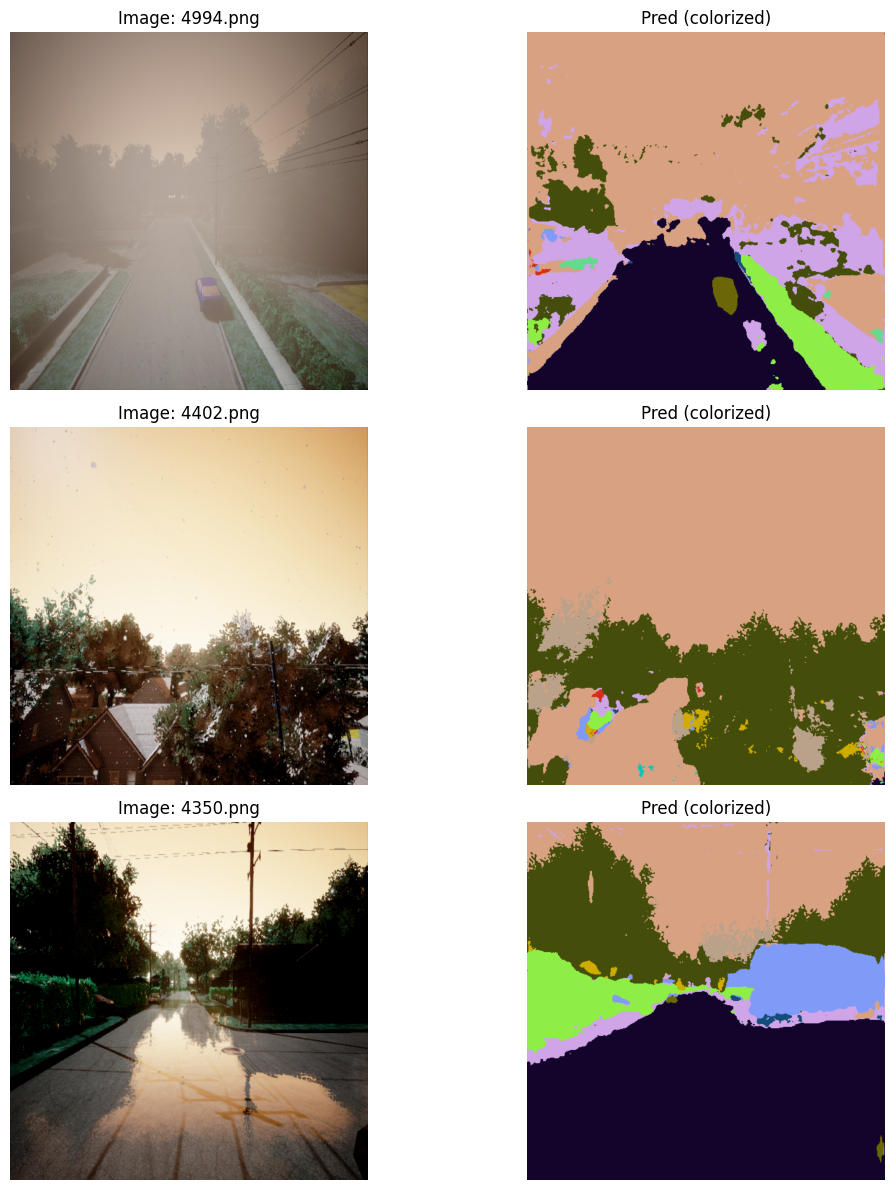

In [13]:
# ==== (Optional) Visualize a few predictions ====
import numpy as np
import matplotlib.pyplot as plt


def colorize_mask(mask, num_classes=16, seed=0):
    rng = np.random.default_rng(seed)
    palette = (rng.integers(0, 255, size=(num_classes, 3))).astype(np.uint8)
    h, w = mask.shape
    color = np.zeros((h, w, 3), dtype=np.uint8)
    for c in range(num_classes):
        color[mask == c] = palette[c]
    return color


n_show = 3
idxs = np.random.choice(len(test_set), size=min(n_show, len(test_set)), replace=False)
plt.figure(figsize=(12, 4 * n_show))

for i, idx in enumerate(idxs, start=1):
    img, fname = test_set[idx]
    with torch.no_grad():
        pred = (
            model(img.unsqueeze(0).to(device))
            .argmax(1)
            .squeeze(0)
            .cpu()
            .numpy()
            .astype(np.uint8)
        )
    pred = cv2.resize(pred, (W, H), interpolation=cv2.INTER_NEAREST)

    # denormalize image (visual only)
    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    plt.subplot(n_show, 2, 2 * i - 1)
    plt.imshow(img_np)
    plt.title(f"Image: {fname}")
    plt.axis("off")

    plt.subplot(n_show, 2, 2 * i)
    plt.imshow(colorize_mask(pred, CFG["num_classes"]))
    plt.title("Pred (colorized)")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
print("Inference complete. Submission saved at:", CFG["out_csv"])

Inference complete. Submission saved at: /homes/nfs/ben/project/AI-pruning-project/kaggle/submission.csv


In [15]:
!kaggle competitions submit \
  -c 2025-ncku-ee-ml-16-classes-segmentation \
  -f /homes/nfs/ben/project/AI-pruning-project/kaggle/submission.csv \
  -m "finetuned Unet++ efficientnet-b5 (1024 resize, RLE F-order, hflip TTA)"


100%|████████████████████████████████████████| 129M/129M [00:06<00:00, 21.2MB/s]
Successfully submitted to 2025 NCKU EE ML UAV Segmentation

In [3]:
import hashlib, os, pandas as pd, time, json, subprocess, shlex

SUB = "/homes/nfs/ben/project/AI-pruning-project/kaggle/submission.csv"
md5 = hashlib.md5(open(SUB, "rb").read()).hexdigest()[:12]
size = os.path.getsize(SUB)
df = pd.read_csv(SUB)
print("rows:", len(df), "bytes:", size, "md5:", md5)
print(df.columns.tolist()[:5], "...", df.columns.tolist()[-3:])

# 建議把 md5 寫進 Kaggle 訊息
msg = f"deeplabv3+ r101 | 1024 NN-resize | F-order RLE | md5={md5}"
cmd = f'kaggle competitions submit -c 2025-ncku-ee-ml-16-classes-segmentation -f "{SUB}" -m "{msg}"'
print(cmd)
# subprocess.run(shlex.split(cmd), check=True)  # 你要時再打開

rows: 1000 bytes: 90623524 md5: fdee0cea9b14
['img', 'class_0', 'class_1', 'class_2', 'class_3'] ... ['class_13', 'class_14', 'class_15']
kaggle competitions submit -c 2025-ncku-ee-ml-16-classes-segmentation -f "/homes/nfs/ben/project/AI-pruning-project/kaggle/submission.csv" -m "deeplabv3+ r101 | 1024 NN-resize | F-order RLE | md5=fdee0cea9b14"


In [4]:
import pandas as pd

df = pd.read_csv(SUB)
non_empty = (df.drop(columns=["img"]) != "none").sum()
print("非空RLE數量（1000張測試影像）:")
print(non_empty.sort_values())

非空RLE數量（1000張測試影像）:
class_14      89
class_15     149
class_11     264
class_7      403
class_10     411
class_9      416
class_12     457
class_13     518
class_8      603
class_5      714
class_2      786
class_4      836
class_6      868
class_3      981
class_0      997
class_1     1000
dtype: int64


In [5]:
import numpy as np


def rle_decode(rle, h=1024, w=1024):
    if rle == "none":
        return np.zeros((h, w), np.uint8)
    s = list(map(int, rle.split()))
    starts, lengths = s[0::2], s[1::2]
    starts = np.array(starts) - 1
    ends = starts + np.array(lengths)
    img = np.zeros(h * w, dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape((h, w), order="F")


row = df.sample(1).iloc[0]
recon = np.zeros((1024, 1024), np.uint8)
for c in range(16):
    recon |= rle_decode(row[f"class_{c}"]) * (c + 1)  # 塗色檢查
print("重建單筆成功，像素非零:", recon.sum() > 0)

重建單筆成功，像素非零: True


In [10]:
# ==== Rebuild val loader + reload model + eval at 1024 (one-cell) ====
import os, cv2, numpy as np, torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

DEVICE = "cuda:1" if torch.cuda.is_available() else "cpu"

# paths (依你的專案結構)
train_img_dir = "/homes/nfs/ben/project/AI-pruning-project/kaggle/data/train/imgs"
train_mask_dir = "/homes/nfs/ben/project/AI-pruning-project/kaggle/data/train/masks"
ckpt_path = "/homes/nfs/ben/project/AI-pruning-project/kaggle/best_model.pth"

# --- transforms (val/test 規格一致) ---
val_tf = A.Compose(
    [
        A.Resize(512, 512),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)


# --- dataset that accepts a subset file list ---
class SegSubset(Dataset):
    def __init__(self, img_dir, mask_dir, fnames, transform):
        self.img_dir, self.mask_dir = img_dir, mask_dir
        self.fnames = sorted(fnames)
        self.tf = transform

    def __len__(self):
        return len(self.fnames)

    def __getitem__(self, i):
        f = self.fnames[i]
        img = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, f)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.mask_dir, f), cv2.IMREAD_GRAYSCALE)
        out = self.tf(image=img, mask=mask)
        return out["image"], out["mask"].long()


# --- split train/val (與你先前 notebook 相同隨機種子) ---
all_pngs = sorted([f for f in os.listdir(train_img_dir) if f.endswith(".png")])
train_imgs, val_imgs = train_test_split(all_pngs, test_size=0.2, random_state=42)
val_set = SegSubset(train_img_dir, train_mask_dir, val_imgs, val_tf)
val_loader = DataLoader(
    val_set, batch_size=8, shuffle=False, num_workers=2, pin_memory=True
)

# --- build model and load ckpt (與提交一致：DeepLabV3Plus-ResNet101, 16 classes) ---
model = smp.DeepLabV3Plus(
    encoder_name="resnet101", encoder_weights=None, classes=16, activation=None
).to(DEVICE)
state = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

# --- mIoU@1024 計算（val 亦回縮到 1024 再算） ---
import cv2, numpy as np


def miou_on_loader_upsampled(
    model, loader, device="cuda", n_classes=16, H=1024, W=1024
):
    inter = np.zeros(n_classes, dtype=np.float64)
    uni = np.zeros(n_classes, dtype=np.float64)
    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            pred = model(imgs).argmax(1).cpu().numpy().astype(np.uint8)
            gt = masks.numpy().astype(np.uint8)
            for p, g in zip(pred, gt):
                p = cv2.resize(p, (W, H), interpolation=cv2.INTER_NEAREST)
                g = cv2.resize(g, (W, H), interpolation=cv2.INTER_NEAREST)
                for c in range(n_classes):
                    pi, gi = (p == c), (g == c)
                    inter[c] += np.logical_and(pi, gi).sum()
                    uni[c] += np.logical_or(pi, gi).sum()
    iou = inter / (uni + 1e-6)
    return float(np.nanmean(iou)), iou


miou_1024, per_cls = miou_on_loader_upsampled(
    model, val_loader, DEVICE, n_classes=16, H=1024, W=1024
)
print("Val mIoU (resize->1024) =", round(miou_1024, 4))
print("Per-class IoU (0..15):", np.round(per_cls, 3))

/tmp/ipykernel_38822/3154961553.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=DEVICE)


RuntimeError: Error(s) in loading state_dict for DeepLabV3Plus:
	Missing key(s) in state_dict: "encoder.conv1.weight", "encoder.bn1.weight", "encoder.bn1.bias", "encoder.bn1.running_mean", "encoder.bn1.running_var", "encoder.layer1.0.conv1.weight", "encoder.layer1.0.bn1.weight", "encoder.layer1.0.bn1.bias", "encoder.layer1.0.bn1.running_mean", "encoder.layer1.0.bn1.running_var", "encoder.layer1.0.conv2.weight", "encoder.layer1.0.bn2.weight", "encoder.layer1.0.bn2.bias", "encoder.layer1.0.bn2.running_mean", "encoder.layer1.0.bn2.running_var", "encoder.layer1.0.conv3.weight", "encoder.layer1.0.bn3.weight", "encoder.layer1.0.bn3.bias", "encoder.layer1.0.bn3.running_mean", "encoder.layer1.0.bn3.running_var", "encoder.layer1.0.downsample.0.weight", "encoder.layer1.0.downsample.1.weight", "encoder.layer1.0.downsample.1.bias", "encoder.layer1.0.downsample.1.running_mean", "encoder.layer1.0.downsample.1.running_var", "encoder.layer1.1.conv1.weight", "encoder.layer1.1.bn1.weight", "encoder.laye